<a href="https://colab.research.google.com/github/MBKNgcobo/Python_projects/blob/main/Consumer_Purchase_Intention_In_Soweto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#EDA of Consumer Purchase Intention In Soweto
Source :  *https://www.sciencedirect.com/science/article/pii/S2352340922003043*

# Predicting Purchase Intention in Subsistence Retail

## Research Objective

This analysis aims to explore the key factors that influence **Purchase Intention (PI)** among consumers in subsistence retail stores in Soweto.

Purchase Intention is measured using:

- **PI1:** "I intend to purchase from this grocery store."
- **PI3:** "I would purchase from this grocery store in the future."

The objective is to identify the **four questions/factors that provide the strongest indication of a customer's likelihood to purchase from the store**.

### Research Question

> **"If a person walks into a subsistence retail store in Soweto, which four questions can the retailer ask the person to determine how likely the person is to purchase something at the store on that day?"**

To answer this question, the analysis will examine the relationship between Purchase Intention and the consumer-related factors measured in the dataset, including **price sensitivity, perceived product quality, customer trust, convenience, perceived value, physical environment, and empathy**.

The analysis will ultimately identify the **four most informative questions** that could be used as a practical, simplified indicator of purchase likelihood.

##1. Installing Python Libraries

In [ ]:
!pip install pandas
!pip install numpy
!pip install seaborn as sea
!pip install plotnine as p9
!pip install great_tables
!pip install skimpy
!pip install great_tables
!pip install metplotlib
!pip install plotly #for funnel and gauge

ERROR: Could not find a version that satisfies the requirement as (from versions: none)
ERROR: No matching distribution found for as
ERROR: Could not find a version that satisfies the requirement as (from versions: none)
ERROR: No matching distribution found for as
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.1/51.1 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 607.2/607.2 kB 37.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 6.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.2/117.2 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 107.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 63.3 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.

##2. Importing Libraries

In [ ]:
import statsmodels.api as sm
import matplotlib.pyplot as plt
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from great_tables import md, html
import great_tables as gt
import numpy as np
import re
import skimpy
import plotnine as p9
import plotly.graph_objects as go #for funnel and guage
%matplotlib inline
from plotnine import (
ggplot,
aes,
after_stat,
stage,
geom_bar,
geom_line,
geom_point,
geom_boxplot,
geom_area,
geom_histogram,
geom_errorbar,
geom_text,
geom_label,
coord_flip
 )


import plotnine as p9
p9.theme_set(p9.theme_minimal())

##3. Importing and reading excel file

In [ ]:

from google.colab import files
upload = files.upload() ##must just locate and upload the excel file - the name must be the same - the filepath doesn't matter
df = pd.read_excel('Subsistence Retail Consumer Data.xlsx')


Saving Subsistence Retail Consumer Data.xlsx to Subsistence Retail Consumer Data (1).xlsx


##4. Cleaning dataset and generating skipmy report of cleaned dataframe

In [ ]:
offending_rows= df[df.notna()]
print(offending_rows)
df = df[['PS2', 'CT1', 'PV1', 'PPQ1', 'PI1','PI3']].dropna()
sns.set(style='whitegrid')
skimpy.skim(df)

     Gender  Age  Marital Status  Employment Status  Level of Education  \
0         3    4               1                  1                   4   
1         3    5               3                  1                   4   
2         2    4               2                  2                   2   
3         1    3               1                  1                   3   
4         3    2               1                  2                   2   
..      ...  ...             ...                ...                 ...   
276       1    3               1                  2                   3   
277       2    3               3                  1                   2   
278       2    4               3                  1                   3   
279       2    5               2                  2                   3   
280       2    5               1                  1                   2   

     Regular Customer  Shopping frequency  E1  E2  E3  ...  CT5  CT6  CT7  \
0                   2 

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 281    │ │ int64       │ 6     │                                                          │
│ │ Number of columns │ 6      │ └─────────────┴───────┘                                                          │
│ └───────────────────┴────────┘                                                                                  │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━┳━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━┓  │
│ ┃ column     ┃ NA   ┃ NA %    ┃ mean      ┃ sd         ┃ p0   ┃ p25    ┃ p50    ┃ p75   ┃ p100    ┃ hist     ┃  │
│ ┡━━━━━━━━━━━━╇━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━┩  │
│ │ PS2        │    0 │       0 │     3.043 │      1.236 │    1 │      2 │      3 │     4 │       5 │  ▄▆ ██▃  │  │
│ │ CT1        │    0 │       0 │     3.431 │      1.208 │    1 │      3 │      4 │     4 │       5 │  ▂▃ ▆█▅  │  │
│ │ PV1        │    0 │       0 │     3.221 │      1.147 │    1 │      2 │      3 │     4 │       5 │  ▂▅ ▇█▃  │  │
│ │ PPQ1       │    0 │       0 │     3.584 │      1.175 │    1 │      3 │      4 │     4 │       5 │  ▂▁ ▅█▅  │  │
│ │ PI1        │    0 │       0 │     3.797 │     0.9209 │    1 │      3 │      4 │     4 │       5 │   ▁ ▃█▄  │  │
│ │ PI3        │    0 │       0 │     3.754 │      1.059 │    1 │      3 │      4 │     5 │       5 │  ▁▂ ▄█▅  │  │
│ └────────────┴──────┴─────────┴───────────┴────────────┴──────┴────────┴────────┴───────┴─────────┴──────────┘  │
╰────────────────────────────────────────────────────── End ──────────────────────────────────────────────────────╯

##5. Add 6 new description columns (PI1_desc, PI3_des, CT1_desc, PS2_desc, PPQ1_desc, and PV1_desc) based on the Likert scale values.


In [ ]:
# Defining Likert scale descriptions
likert_map = {
    1: "Strongly Disagree",
    2: "Disagree",
    3: "Neutral",
    4: "Agree",
    5: "Strongly Agree"
}

# Applying mapping to relevant columns
df['PI1_desc']  = df['PI1'].map(likert_map)
df['PI3_desc']  = df['PI3'].map(likert_map)
df['CT1_desc']  = df['CT1'].map(likert_map)
df['PS2_desc']  = df['PS2'].map(likert_map)
df['PPQ1_desc'] = df['PPQ1'].map(likert_map)
df['PV1_desc']  = df['PV1'].map(likert_map)

# Previewing result
df[['PI1', 'PI1_desc','PI3', 'PI3_desc', 'CT1', 'CT1_desc', 'PS2', 'PS2_desc', 'PPQ1', 'PPQ1_desc', 'PV1', 'PV1_desc']].head()


,PI1,PI1_desc,PI3,PI3_desc,CT1,CT1_desc,PS2,PS2_desc,PPQ1,PPQ1_desc,PV1,PV1_desc
0,3,Neutral,4,Agree,3,Neutral,3,Neutral,3,Neutral,2,Disagree
1,4,Agree,4,Agree,2,Disagree,3,Neutral,1,Strongly Disagree,2,Disagree
2,3,Neutral,4,Agree,3,Neutral,3,Neutral,3,Neutral,2,Disagree
3,3,Neutral,3,Neutral,2,Disagree,5,Strongly Agree,3,Neutral,1,Strongly Disagree
4,2,Disagree,2,Disagree,3,Neutral,2,Disagree,3,Neutral,2,Disagree


##6. Regression Analysis (Using PI1 and PI3 - regression done separately for both)

6.1 Regression analysis using PI1

In [ ]:
cols = ['CT1', 'PS2', 'PV1', 'PPQ1', 'PI1']
regression_data = df[cols].dropna()


X = regression_data[['CT1', 'PS2', 'PV1', 'PPQ1']]
y = regression_data['PI1']

# Add constant (intercept)
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    PI1   R-squared:                       0.360
Model:                            OLS   Adj. R-squared:                  0.350
Method:                 Least Squares   F-statistic:                     38.74
Date:                Wed, 14 May 2025   Prob (F-statistic):           9.97e-26
Time:                        09:24:14   Log-Likelihood:                -312.45
No. Observations:                 281   AIC:                             634.9
Df Residuals:                     276   BIC:                             653.1
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.0481      0.169     12.136      0.0

6.2 Regression analysis using PI3

In [ ]:
cols = ['CT1', 'PS2', 'PV1', 'PPQ1','PI3']
regression_data = df[cols].dropna()


X = regression_data[['CT1', 'PS2', 'PV1', 'PPQ1']]
y = regression_data['PI3']

# Add constant (intercept)
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    PI3   R-squared:                       0.342
Model:                            OLS   Adj. R-squared:                  0.332
Method:                 Least Squares   F-statistic:                     35.79
Date:                Wed, 14 May 2025   Prob (F-statistic):           4.36e-24
Time:                        09:24:57   Log-Likelihood:                -355.64
No. Observations:                 281   AIC:                             721.3
Df Residuals:                     276   BIC:                             739.5
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.7579      0.197      8.933      0.0

##7. Interpretation of Regression Analysis


PV1 (Perceived Value) and PPQ1 (Product Quality) are the strongest drivers of Purchase Intention (for both PI1 and PI3).

PS2 (possibly Perceived Sustainability or Satisfaction) has a modest but significant positive impact.

CT1 (Customer Trust or Expectation match) is not statistically significant at the 5% level but is borderline.

##Correlation Heatmap: Predictors vs Purchase intention

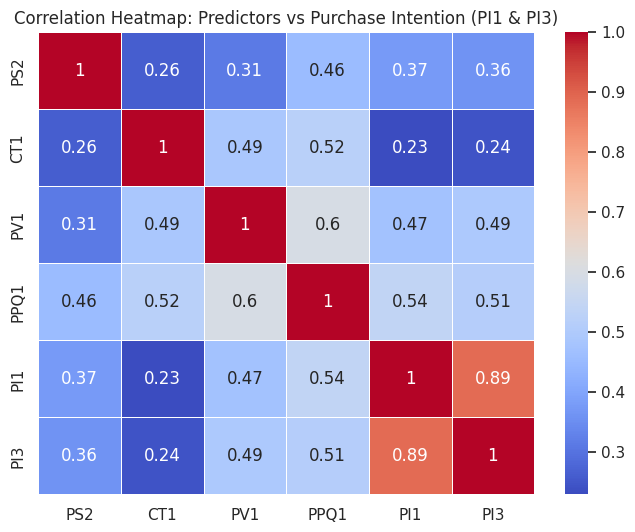

In [ ]:
# Define variables including PI3
corr_vars = ['PS2', 'CT1', 'PV1', 'PPQ1', 'PI1', 'PI3']
df_corr = df[corr_vars].dropna()

# Compute correlation matrix
corr_matrix = df_corr.corr()

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap: Predictors vs Purchase Intention (PI1 & PI3)")
plt.show()

##Analysis for Correlation Heatmap
This correlation heatmap shows how different predictors (survey variables) are statistically associated with Purchase Intention (PI1) and with each other. The values in each cell represent the Pearson correlation coefficient (range: -1 to +1), where:

1. 1.0 indicates a perfect positive correlation.

2. 0 indicates no correlation.

3. -1.0 indicates a perfect negative correlation.

##Results
PPQ1 (0.51): Strongest correlation with purchase intention. Product quality is an indirect key driver.

PV1 (0.49): Perceived value is also strongly correlated.

PS2 (0.36): Moderate correlation.

CT1 (0.24): Lowest correlation among predictors.

There's a general pattern of moderate to strong positive correlations among all predictors, indicating interconnected consumer perceptions.

##8. Gauge Chart with 5-point likert range for all variables to be analysed - using their respective averages (mean)

In [ ]:
# Calculate average values
averages = {
    'PI1': df['PI1'].mean(),
    'PI3': df['PI3'].mean(),
    'PS2': df['PS2'].mean(),
    'CT1': df['CT1'].mean(),
    'PV1': df['PV1'].mean(),
    'PPQ1': df['PPQ1'].mean()
}

# Create subplots dynamically
num_charts = len(averages)
fig = make_subplots(
    rows=1, cols=num_charts,
    specs=[[{'type': 'indicator'}]*num_charts],
    subplot_titles=list(averages.keys())
)

# Add gauge charts
for i, (variable, avg) in enumerate(averages.items()):
    fig.add_trace(
        go.Indicator(
            mode="gauge+number",
            value=avg,
            gauge={
                'axis': {'range': [1, 5], 'tickvals': [1, 2, 3, 4, 5]},
                'bar': {'color': 'skyblue'},
                'bgcolor': 'lightgrey',
                'steps': [{'range': [1, 5], 'color': 'lightgrey'}],
                'threshold': {
                    'line': {'color': 'black', 'width': 4},
                    'thickness': 0.75,
                    'value': 3
                }
            }
        ),
        row=1, col=i+1
    )

# Update layout with additional spacing between main title and subplot titles
fig.update_layout(
    title=dict(
        text="<b>Combined Gauge Chart of Averages (Target = 3)</b>",
        x=0.5,
        y=0.95,  # Lower it slightly to leave space below
        font=dict(size=20),
        pad=dict(b=30)  # Adds padding below the title
    ),
    height=350,
    width=200 * num_charts,
    margin=dict(t=100, b=30)  # Top margin allows space for title and padding
)

fig.show()

The respective gauges show that most people showed support for each variable statement as the averages exceed the target point of nuetrality (3)

##9. Funnels to show distribution of responses

In [ ]:
# Define variable-desc pairs
variables = [
    ('PI1', 'PI1_desc'),
    ('PI3', 'PI3_desc'),
    ('PS2', 'PS2_desc'),
    ('CT1', 'CT1_desc'),
    ('PV1', 'PV1_desc'),
    ('PPQ1', 'PPQ1_desc')
]

# Create 1-row, 6-column subplot layout
fig = make_subplots(
    rows=1,
    cols=6,
    subplot_titles=[var[0] for var in variables],
    specs=[[{'type': 'funnel'}]*6]
)

# Loop over each variable pair and add funnel chart
for i, (var, desc_var) in enumerate(variables):
    counts = df[desc_var].value_counts().reset_index()
    counts.columns = [desc_var, 'Count']
    counts = counts.sort_values(by='Count', ascending=False)

    funnel = go.Funnel(
        y=counts[desc_var],
        x=counts['Count'],
        textinfo='value+label',
        name=var
    )

    fig.add_trace(funnel, row=1, col=i+1)

    # Remove y-axis tick labels (left-side labels)
    fig.update_yaxes(showticklabels=False, row=1, col=i+1)

# Update layout
fig.update_layout(
    title_text="<b>Funnel Charts of Response Distributions</b>",
    title_x=0.5,
    height=600,
    width=1800,
    margin=dict(t=80, b=50, l=20, r=20)
)

fig.show()

The funnels show us that majority of people support the statements of the respective variables. The funnels give us the number of people per category of response.

##10. Other charts/graphs and their analysis - specific to PI drivers

##10.1 PS2: (“I am willing to pay a higher price for the benefit of having the grocery store located close to me”)

<ipython-input-30-6e8fad34014a>:8: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


<ipython-input-30-6e8fad34014a>:14: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




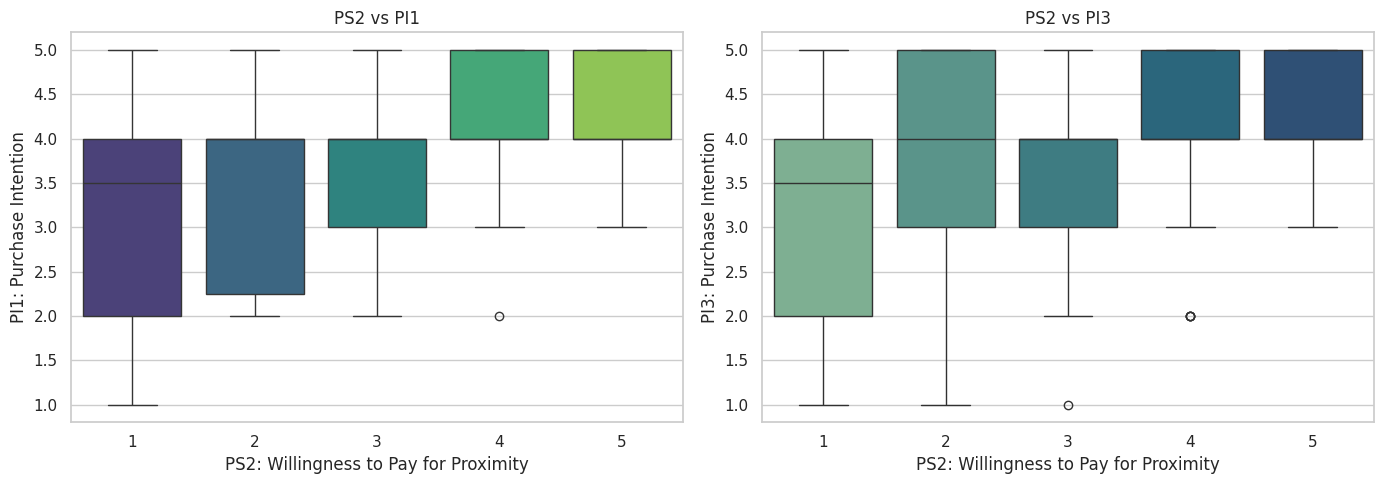

Correlation (PS2 vs PI1): 0.37
Correlation (PS2 vs PI3): 0.36


In [ ]:
# Set seaborn style
sns.set(style='whitegrid')

# Create 1 row, 2 columns of boxplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Boxplot 1: PS2 vs PI1 ---
sns.boxplot(x='PS2', y='PI1', data=df, palette='viridis', ax=axes[0])
axes[0].set_title('PS2 vs PI1')
axes[0].set_xlabel('PS2: Willingness to Pay for Proximity')
axes[0].set_ylabel('PI1: Purchase Intention')

# --- Boxplot 2: PS2 vs PI3 ---
sns.boxplot(x='PS2', y='PI3', data=df, palette='crest', ax=axes[1])
axes[1].set_title('PS2 vs PI3')
axes[1].set_xlabel('PS2: Willingness to Pay for Proximity')
axes[1].set_ylabel('PI3: Purchase Intention')

# Adjust layout
plt.tight_layout()
plt.show()

# --- Correlations ---
corr_ps2_pi1 = df['PS2'].corr(df['PI1'])
corr_ps2_pi3 = df['PS2'].corr(df['PI3'])

print(f'Correlation (PS2 vs PI1): {corr_ps2_pi1:.2f}')
print(f'Correlation (PS2 vs PI3): {corr_ps2_pi3:.2f}')

##Analysis of Price Sensitivity on Purchasing Intention.
As PS2 increases, the median and overall distribution of PI also increase.
This suggests that people more willing to pay for store proximity tend to have higher purchase intentions..This plot supports the idea that greater willingness to pay for proximity correlates with higher purchase intention, which could be valuable for retail location strategies and pricing models.

Correlation (PS2 vs PI1): 0.37 (strongest correlation coefficient as compared to PS2 vs PI3)

Correlation (PS2 vs PI3): 0.36

##10.2 CT1:  (“The grocery store always meets my expectations”)

<ipython-input-31-c49762dcef31>:8: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


<ipython-input-31-c49762dcef31>:14: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




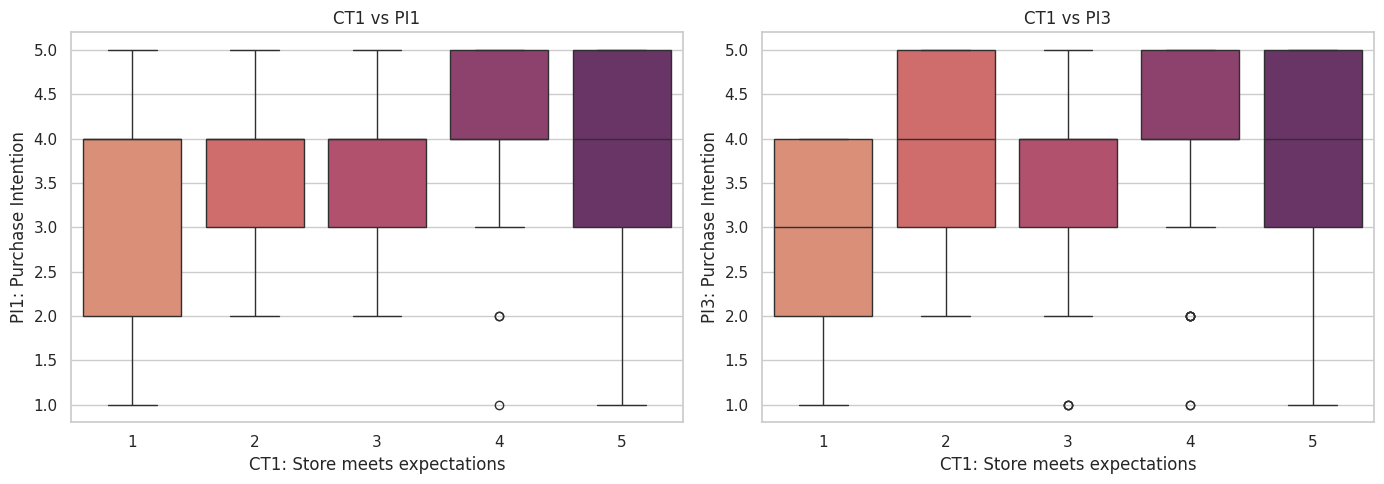

Correlation (CT1 vs PI1): 0.23
Correlation (CT1 vs PI3): 0.24


In [ ]:
# Set seaborn style
sns.set(style='whitegrid')

# Create subplots: 1 row, 2 columns
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Boxplot 1: CT1 vs PI1 ---
sns.boxplot(x='CT1', y='PI1', data=df, palette='flare', ax=axes[0])
axes[0].set_title('CT1 vs PI1')
axes[0].set_xlabel('CT1: Store meets expectations')
axes[0].set_ylabel('PI1: Purchase Intention')

# --- Boxplot 2: CT1 vs PI3 ---
sns.boxplot(x='CT1', y='PI3', data=df, palette='flare', ax=axes[1])
axes[1].set_title('CT1 vs PI3')
axes[1].set_xlabel('CT1: Store meets expectations')
axes[1].set_ylabel('PI3: Purchase Intention')

# Adjust layout
plt.tight_layout()
plt.show()

# --- Correlations ---
corr_ct1_pi1 = df['CT1'].corr(df['PI1'])
corr_ct1_pi3 = df['CT1'].corr(df['PI3'])

print(f'Correlation (CT1 vs PI1): {corr_ct1_pi1:.2f}')
print(f'Correlation (CT1 vs PI3): {corr_ct1_pi3:.2f}')

##Analysis of CT1 on Purchasing Intention
There is a slightly increasing trend in purchase intention as CT1 increases.
Customers who strongly agree (CT1 = 5) that the store meets expectations tend to show higher purchase intention.
CT1 = 1 and CT1 = 5 show wider spread and more outliers, suggesting diverse customer opinions.
CT1 = 2 has a tighter distribution, indicating more consistent perceptions among those respondents.
While not as strong as the product quality (PPQ1) effect seen earlier, there is still a positive relationship between customers’ expectations being met and their purchase intention. This supports the idea that customer satisfaction plays a meaningful role in driving intent to buy.

Correlation (CT1 vs PI1): 0.23

Correlation (CT1 vs PI3): 0.24 (strongest correlation coefficient as compared to CT1 vs PI1)

##10.3 PV1: (“The grocery store’s products have good value for money”)

<ipython-input-32-78351d7e9cd0>:8: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


<ipython-input-32-78351d7e9cd0>:14: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




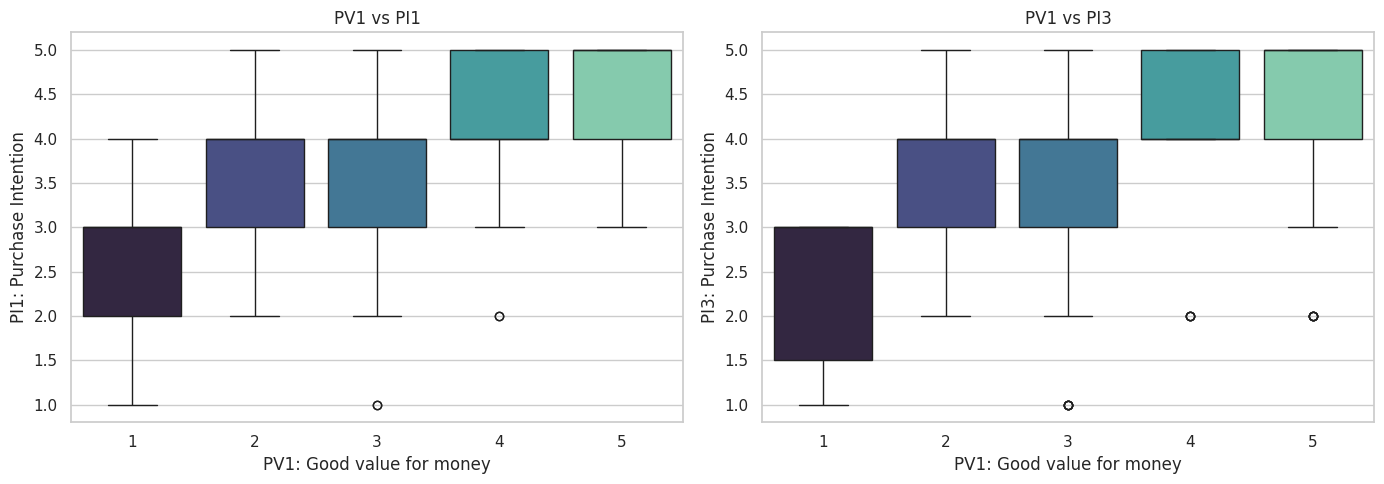

Correlation (PV1 vs PI1): 0.47
Correlation (PV1 vs PI3): 0.49


In [ ]:
# Set seaborn style
sns.set(style='whitegrid')

# Create subplots: 1 row, 2 columns
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Boxplot 1: PV1 vs PI1 ---
sns.boxplot(x='PV1', y='PI1', data=df, palette='mako', ax=axes[0])
axes[0].set_title('PV1 vs PI1')
axes[0].set_xlabel('PV1: Good value for money')
axes[0].set_ylabel('PI1: Purchase Intention')

# --- Boxplot 2: PV1 vs PI3 ---
sns.boxplot(x='PV1', y='PI3', data=df, palette='mako', ax=axes[1])
axes[1].set_title('PV1 vs PI3')
axes[1].set_xlabel('PV1: Good value for money')
axes[1].set_ylabel('PI3: Purchase Intention')

# Adjust layout for spacing
plt.tight_layout()
plt.show()

# --- Correlation calculations ---
corr_pv1_pi1 = df['PV1'].corr(df['PI1'])
corr_pv1_pi3 = df['PV1'].corr(df['PI3'])

print(f'Correlation (PV1 vs PI1): {corr_pv1_pi1:.2f}')
print(f'Correlation (PV1 vs PI3): {corr_pv1_pi3:.2f}')

Correlation (PV1 vs PI1): 0.47

Correlation (PV1 vs PI3): 0.49 (strongest correlation coefficient as compared to PV1 vs PI1)

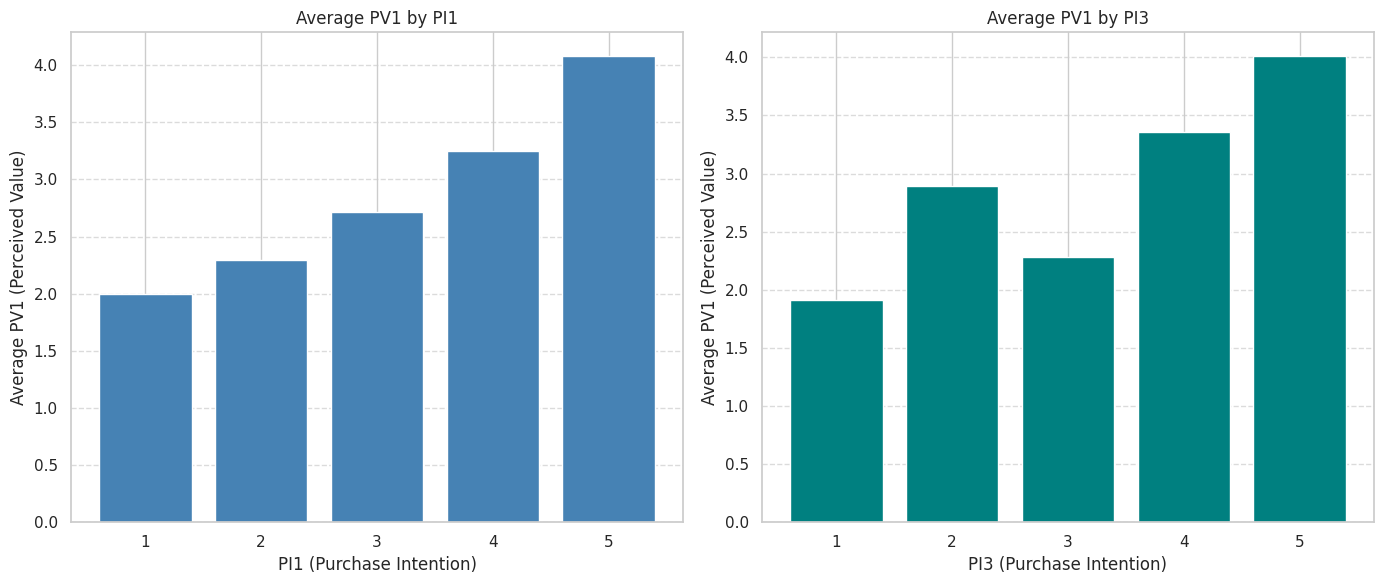

In [ ]:
# --- Group data for both plots ---
grouped_pi1 = df.groupby('PI1')['PV1'].mean().reset_index()
grouped_pi3 = df.groupby('PI3')['PV1'].mean().reset_index()

# --- Create subplots: 1 row, 2 columns ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Bar Chart 1: PV1 by PI1 ---
axes[0].bar(grouped_pi1['PI1'].astype(str), grouped_pi1['PV1'], color='steelblue')
axes[0].set_title('Average PV1 by PI1')
axes[0].set_xlabel('PI1 (Purchase Intention)')
axes[0].set_ylabel('Average PV1 (Perceived Value)')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# --- Bar Chart 2: PV1 by PI3 ---
axes[1].bar(grouped_pi3['PI3'].astype(str), grouped_pi3['PV1'], color='teal')
axes[1].set_title('Average PV1 by PI3')
axes[1].set_xlabel('PI3 (Purchase Intention)')
axes[1].set_ylabel('Average PV1 (Perceived Value)')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

# --- Final layout adjustments ---
plt.tight_layout()
plt.show()

##Analysis of Bar Graph :
As purchase intention increases, the average perceived value (PV1) also increases.Customers who rate their purchase intention as "5" have the highest perceived value (PV1 ≈ 4.0).Customers with low purchase intention (PI1 = 1) perceive significantly less value (PV1 ≈ 1.9).The pattern is mostly upward, though there’s a slight dip at PI1 = 3, suggesting a small group might have moderate purchase intention despite lower perceived value.

There is a strong positive relationship between perceived value (PV1) and purchase intention (PI1). This suggests that improving how valuable the product or service feels to customers can significantly boost their likelihood of making a purchase.

##Analysis of Perceived Value on Purchasing Intention
As PV1 increases, the median and overall level of PI also increase.
Consumers who perceive higher value for money tend to show stronger intent to purchase.This chart indicates a strong positive relationship between perceived value (PV1) and purchase intention (PI). The better consumers think the value for money is, the more likely they are to buy.

##10.4 PPQ1: (“The overall quality of products I buy from the grocery store is good”)

<ipython-input-33-5b384e23b613>:8: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.


<ipython-input-33-5b384e23b613>:14: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




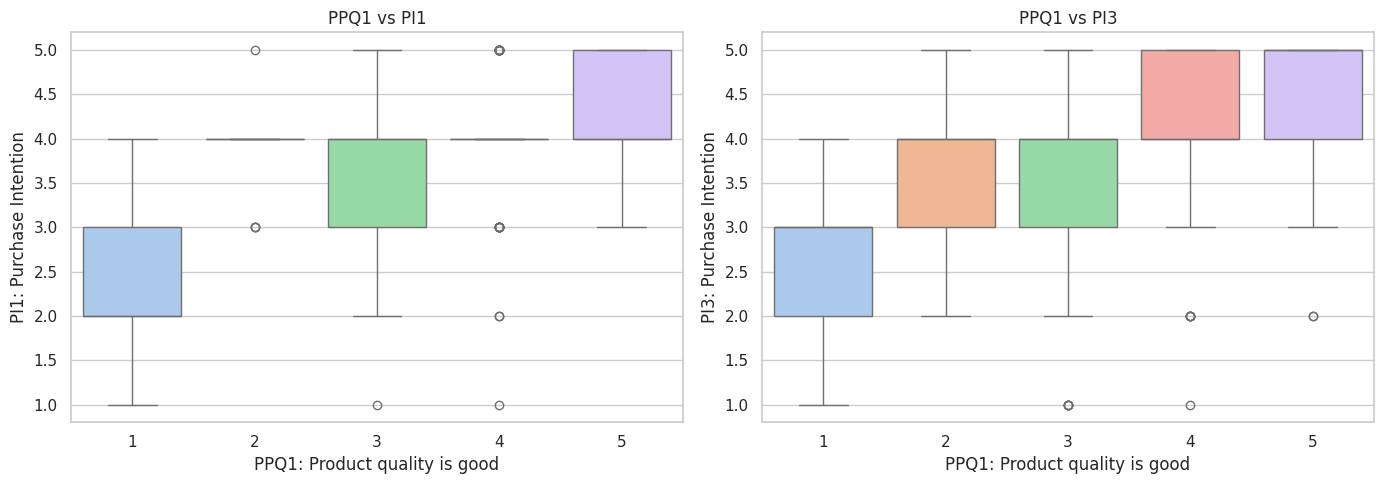

Correlation (PPQ1 vs PI1): 0.54
Correlation (PPQ1 vs PI3): 0.51


In [ ]:
# Set seaborn style
sns.set(style='whitegrid')

# Create subplots: 1 row, 2 columns
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Boxplot 1: PPQ1 vs PI1 ---
sns.boxplot(x='PPQ1', y='PI1', data=df, palette='pastel', ax=axes[0])
axes[0].set_title('PPQ1 vs PI1')
axes[0].set_xlabel('PPQ1: Product quality is good')
axes[0].set_ylabel('PI1: Purchase Intention')

# --- Boxplot 2: PPQ1 vs PI3 ---
sns.boxplot(x='PPQ1', y='PI3', data=df, palette='pastel', ax=axes[1])
axes[1].set_title('PPQ1 vs PI3')
axes[1].set_xlabel('PPQ1: Product quality is good')
axes[1].set_ylabel('PI3: Purchase Intention')

# Adjust layout
plt.tight_layout()
plt.show()

# --- Correlation calculations ---
corr_ppq1_pi1 = df['PPQ1'].corr(df['PI1'])
corr_ppq1_pi3 = df['PPQ1'].corr(df['PI3'])

print(f'Correlation (PPQ1 vs PI1): {corr_ppq1_pi1:.2f}')
print(f'Correlation (PPQ1 vs PI3): {corr_ppq1_pi3:.2f}')

Correlation (PPQ1 vs PI1): 0.54 strongest correlation coefficient as compared to (PPQ1 vs PI3)

Correlation (PPQ1 vs PI3): 0.51

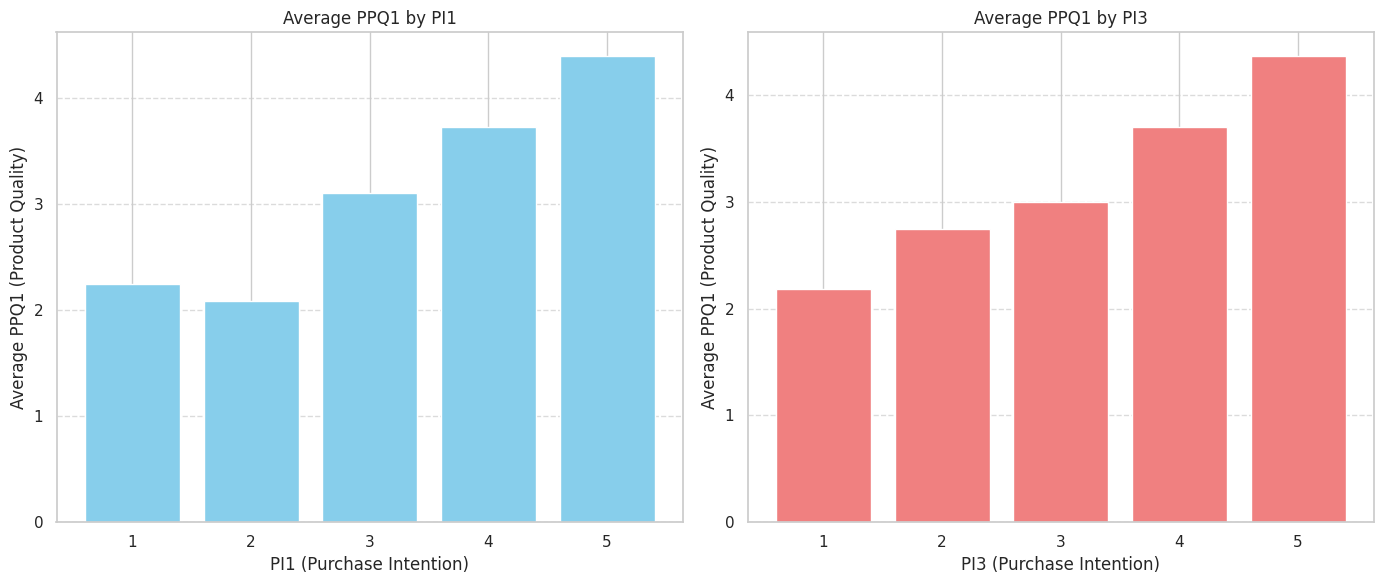

In [ ]:
# --- Grouped data ---
grouped_pi1 = df.groupby('PI1')['PPQ1'].mean().reset_index()
grouped_pi3 = df.groupby('PI3')['PPQ1'].mean().reset_index()

# --- Create subplots: 1 row, 2 columns ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Bar Graph 1: PPQ1 by PI1 ---
axes[0].bar(grouped_pi1['PI1'].astype(str), grouped_pi1['PPQ1'], color='skyblue')
axes[0].set_title('Average PPQ1 by PI1')
axes[0].set_xlabel('PI1 (Purchase Intention)')
axes[0].set_ylabel('Average PPQ1 (Product Quality)')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# --- Bar Graph 2: PPQ1 by PI3 ---
axes[1].bar(grouped_pi3['PI3'].astype(str), grouped_pi3['PPQ1'], color='lightcoral')
axes[1].set_title('Average PPQ1 by PI3')
axes[1].set_xlabel('PI3 (Purchase Intention)')
axes[1].set_ylabel('Average PPQ1 (Product Quality)')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

# --- Final layout adjustments ---
plt.tight_layout()
plt.show()

##Analysis for Bar Graph
There is a clear upward trend: as purchase intention increases, the average perceived product quality also increases.

Customers who rated PI1 as 5 also rated PPQ1 highest (~4.3 – 4.4).

Those who gave the lowest purchase intention (PI1 = 1) rated product quality the lowest (~2.2).The growth appears progressive and consistent, with each step up in PI1 linked to a higher average PPQ1.

This suggests a strong positive relationship between perceived product quality and purchase intention. As customers perceive the product to be of higher quality, they are more inclined to intend to purchase it.

##Analysis for Perceived Product Quality and Purchasing Intention .
As the perceived product quality (PPQ1) increases, the median purchase intention also increases.This suggests a positive relationship between product quality perception and purchase intention.The chart clearly demonstrates that higher perceived product quality leads to higher purchase intention, a common and expected finding in consumer behavior analysis.

## 11. Recommendations & Conclusion

Each variable received strong support, with average responses exceeding the neutral benchmark of 3 on the Likert scale. This reinforces the conclusion that PS, CT, and PV are key drivers of PI, while PPQ contributes indirectly, as confirmed by the regression tests.


As a result, the four relevant questions a retailer can ask a customer are:

1.	Are you willing to pay a higher price for the benefit of having the grocery store located close to you?

2.	Does the grocery store always meet your expectations?

3.	Do the store’s products have good value for money?

4.	Is the overall quality of products that you buy from this grocery store good?